In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

from backtest_functions import simulate_kelly
from backtest_plots import plot_backtest, per_bet_analysis

from backtest_plots import event_analysis, plot_event_odds_stats, correlate_with_vegas, summary_stats, pmf_plot, parlay_analysis


In [ ]:
# https://vegapit.com/article/numerically_solve_kelly_criterion_multiple_simultaneous_bets/
# https://nickyoder.com/kelly-criterion/
# https://www.mma-ai.net/ 

# https://business.columbia.edu/sites/default/files-efs/pubfiles/6343/bayes_kelly.pdf
## Portfolio Choice and the Bayesian Kelly Criterion


c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


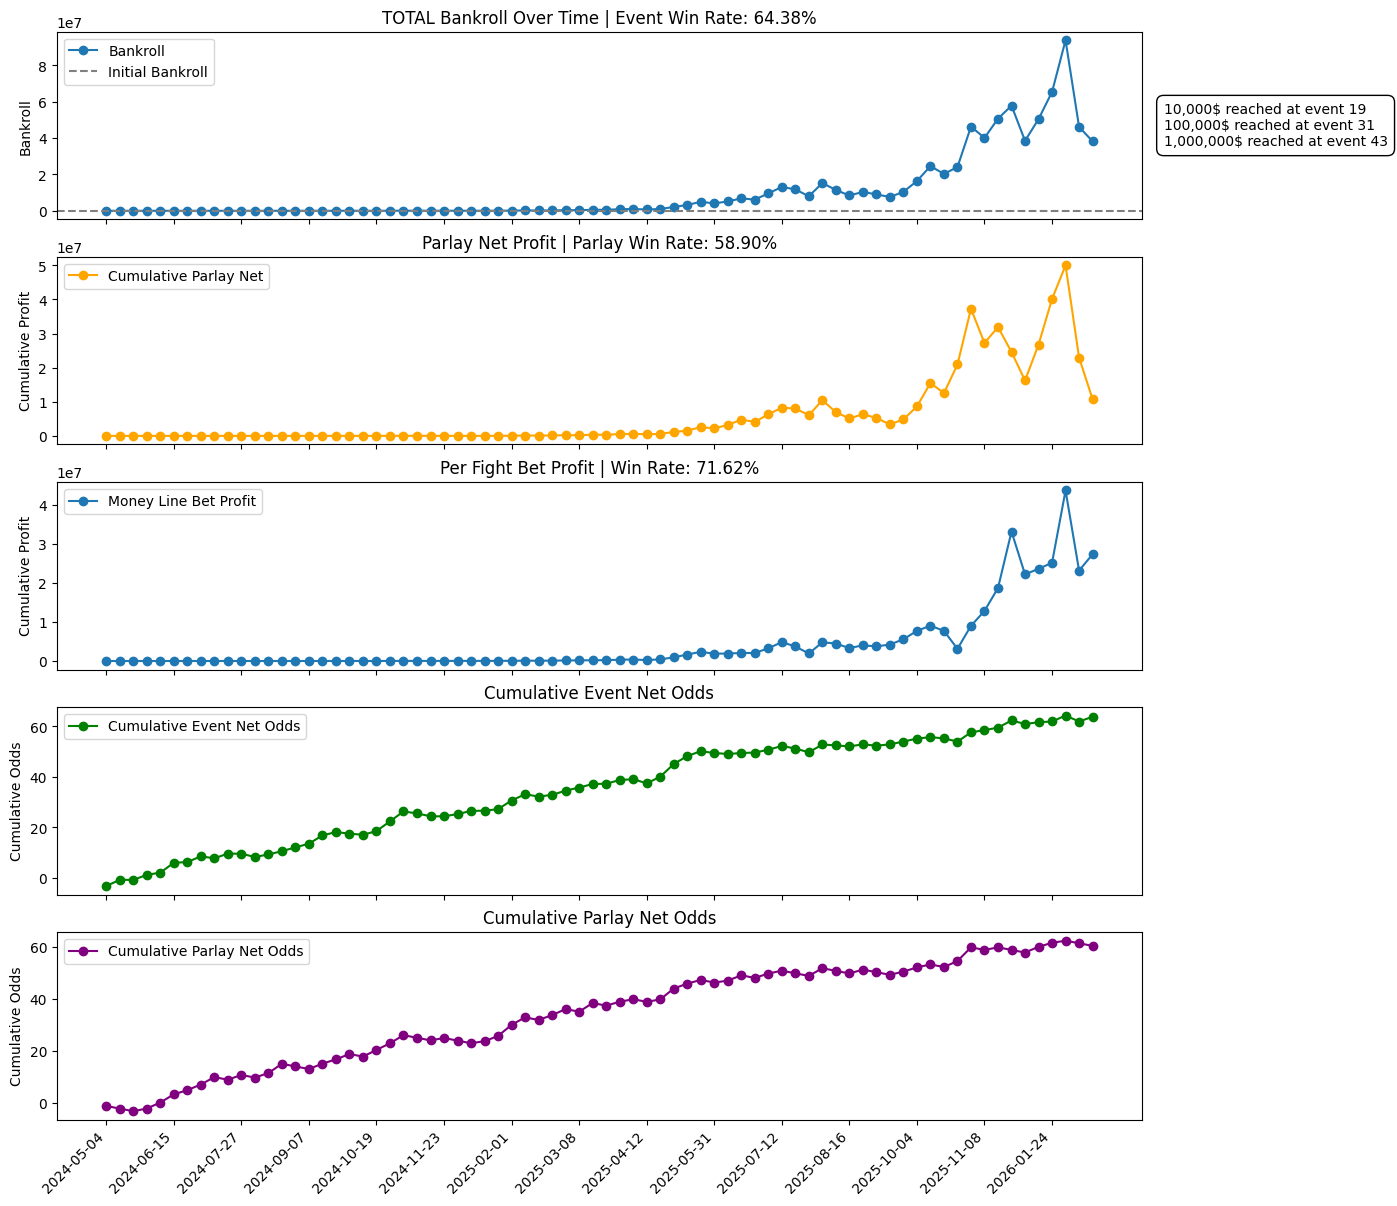

In [2]:
df_test_open = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_open.csv')

prob_cols = ['proba_blue', 'proba_red']
fair_decimal_odds = ['dec_fair_open_blue', 'dec_fair_open_red']  # your decimal odds columns
real_decimal_odds = ['dec_open_blue', 'dec_open_red']

df_kelly, df_parlay = simulate_kelly(
    df_test_open,
    prob_cols=prob_cols,
    fair_decimal_cols=fair_decimal_odds,
    real_decimal_cols=real_decimal_odds,
    pred_winner_col='pred_winner',
    date_col='date',
    init_bankroll=500,
    bankroll_floor=100,
    portfolio_scaling=False,
    adaptive_scaling=True,  
    max_drawdown=.3,
    parlay_mdd=None,
    N=250,
    calc_parlay=True
)

# plot_bankroll_distributions(df_kelly, df_parlay)
plot_fp = r'C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\open_kelly_sim.png'
plot_backtest(df_kelly, 500, path=plot_fp)
# plot_event_odds_stats(df_kelly)

# x_vars = ['mu_portfolio', 'sharpe_portfolio', 'portfolio_sigma']
# y_var = 'event_net_odds'
# kelly_analysis(df_kelly, x_vars, y_var)

df_kelly.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_open.csv')
df_parlay.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\streamlit\data\parlay_open.csv')

c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\_methods.

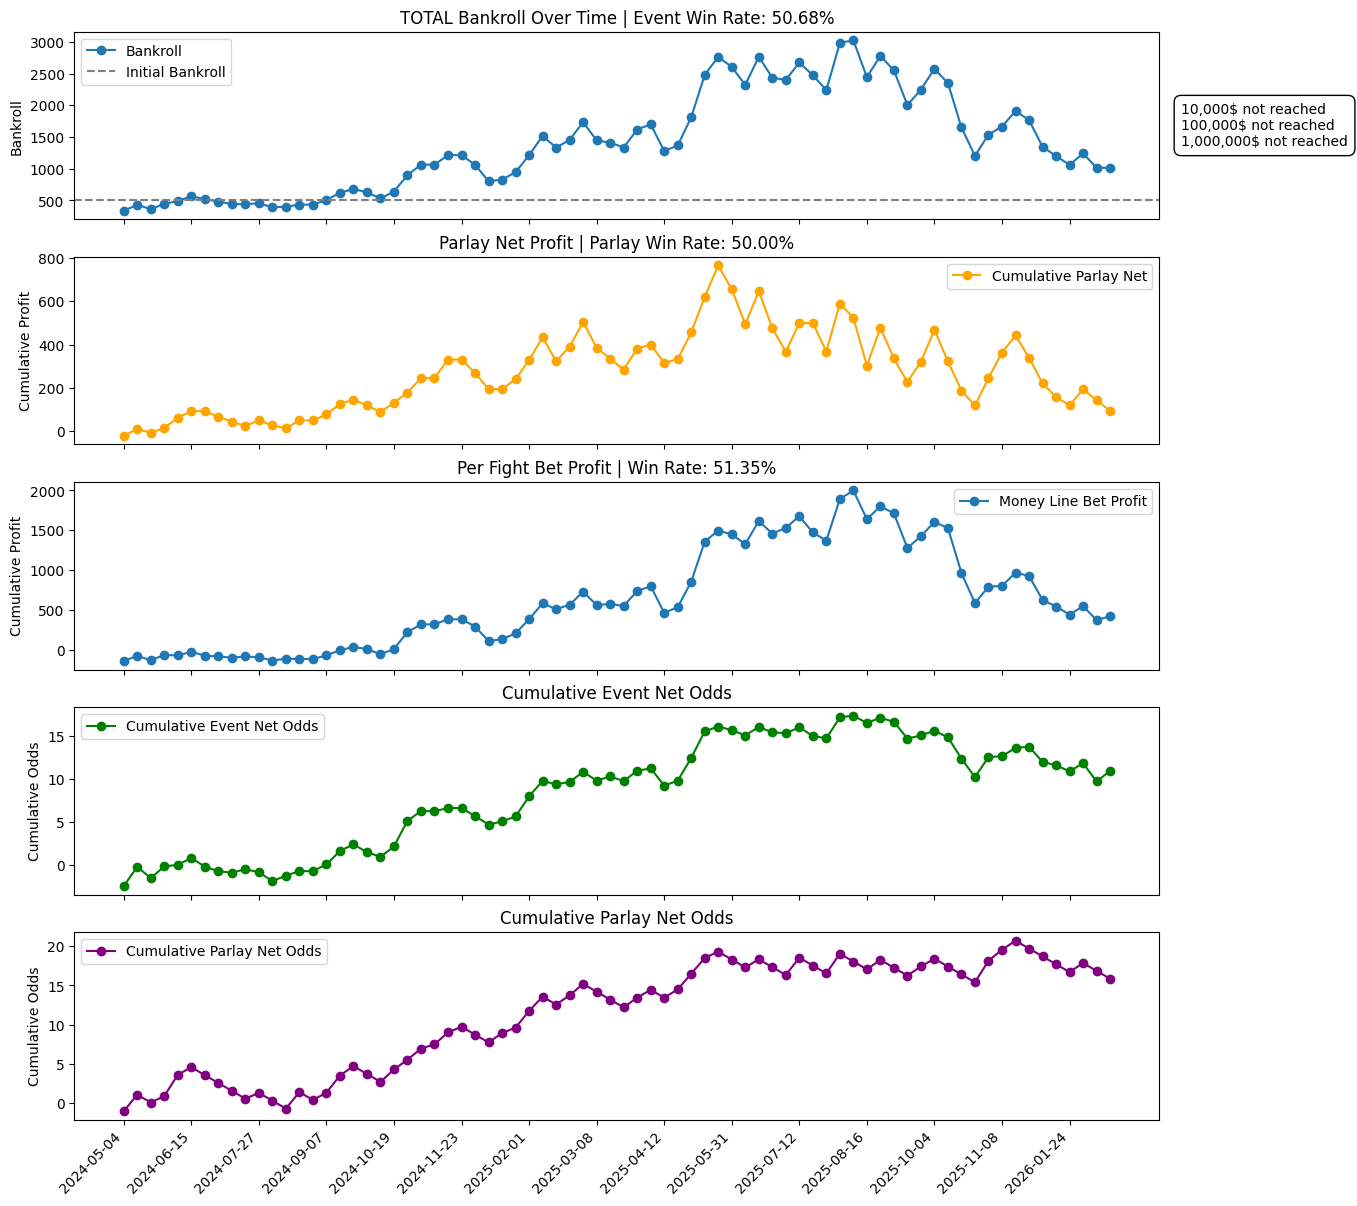

In [3]:
df_test_close = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_close1.csv')

prob_cols = ['proba_blue', 'proba_red']
fair_decimal_odds = ['dec_fair_close1_blue', 'dec_fair_close1_red']  # your decimal odds columns
real_decimal_odds = ['dec_close1_blue', 'dec_close1_red']

df_kelly1, df_kelly1_parlay = simulate_kelly(
    df_test_close,
    prob_cols=prob_cols,
    fair_decimal_cols=fair_decimal_odds,
    real_decimal_cols=real_decimal_odds,
    pred_winner_col='pred_winner',
    date_col='date',
    init_bankroll=500,
    bankroll_floor=100,
    portfolio_scaling=False,
    adaptive_scaling=True,
    max_drawdown=.25,
    N=250,
    calc_parlay=True
)

plot_fp = r'C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\close1_kelly_sim.png'
plot_backtest(df_kelly1, 500, path=plot_fp)

df_kelly1.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_close1.csv')
df_kelly1.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\streamlit\data\kelly_close1.csv')
df_kelly1_parlay.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\streamlit\data\parlay_close1.csv')

c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\jcmar\my_files\SportsBetting\venv\Lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


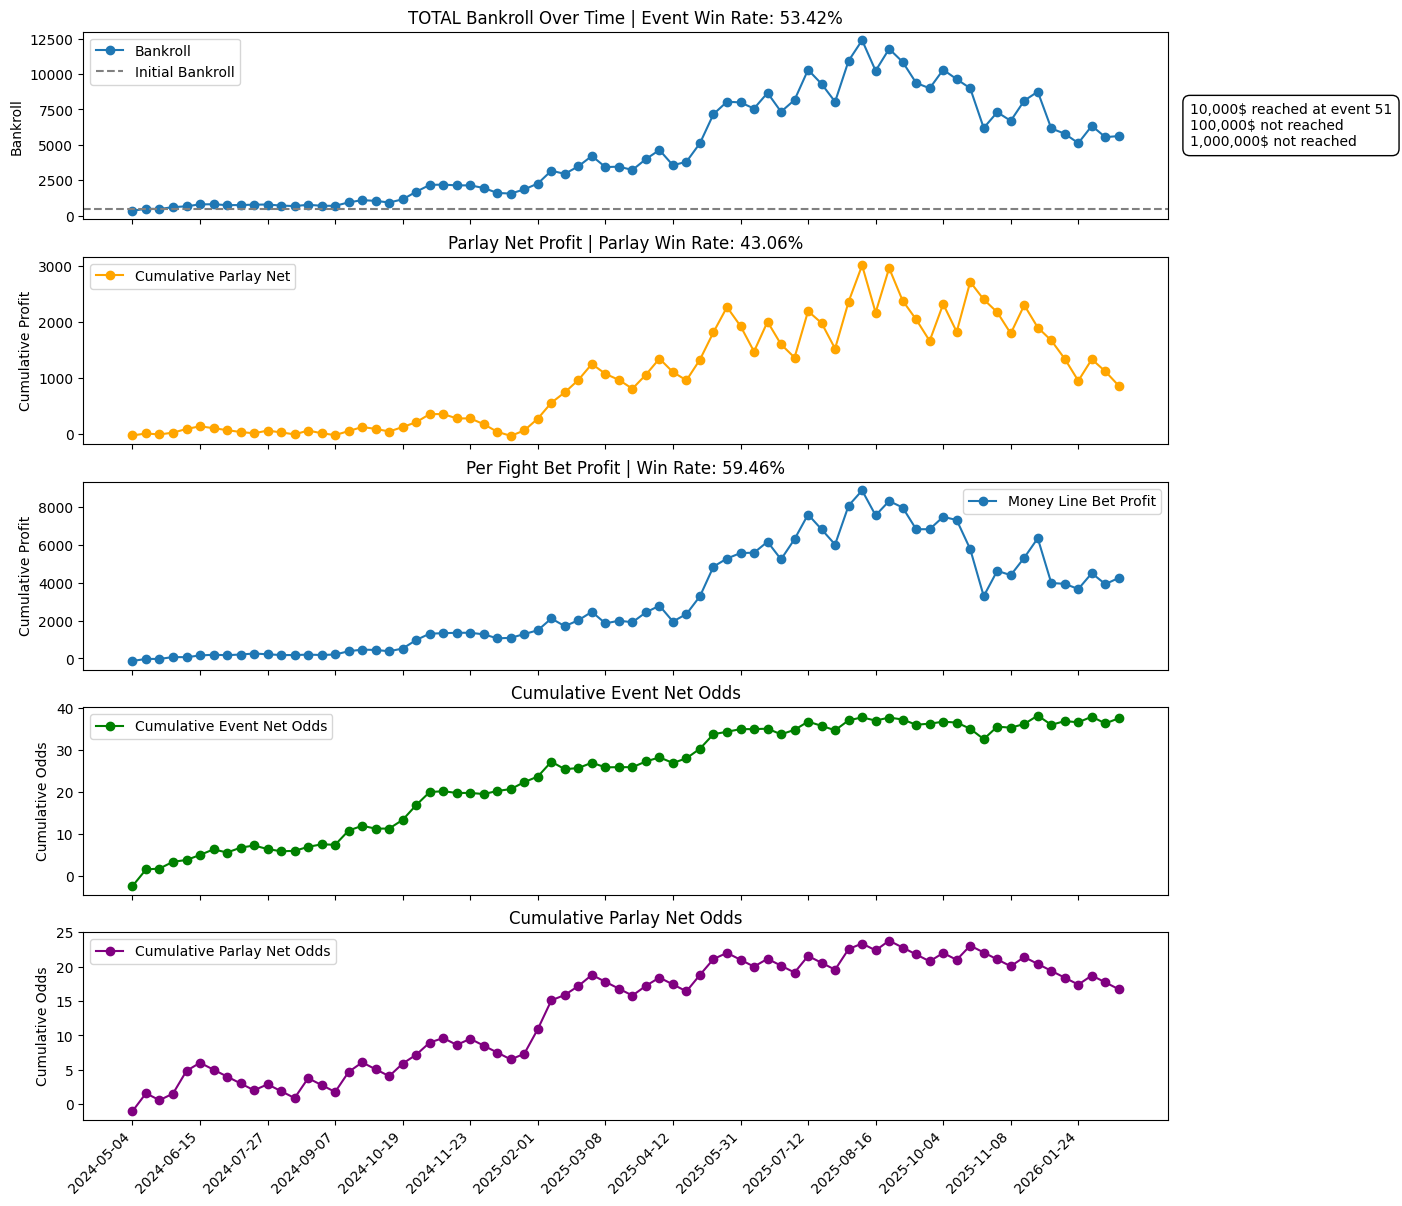

In [4]:
df_test_close = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\model_results\test_logit_close2.csv')


prob_cols = ['proba_blue', 'proba_red']
# fair_decimal_odds = ['dec_fair_open_blue', 'dec_fair_open_red']
fair_decimal_odds = ['dec_fair_close2_blue', 'dec_fair_close2_red']  # your decimal odds columns
real_decimal_odds = ['dec_close2_blue', 'dec_close2_red']
df_kelly2, df_kelly2_parlay = simulate_kelly(
    df_test_close,
    prob_cols=prob_cols,
    fair_decimal_cols=fair_decimal_odds,
    real_decimal_cols=real_decimal_odds,
    pred_winner_col='pred_winner',
    date_col='date',
    init_bankroll=500,
    bankroll_floor=100,
    portfolio_scaling=False,
    adaptive_scaling=True,
    max_drawdown=.25,
    N=250,
    calc_parlay=True
)

plot_fp = r'C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\close2_kelly_sim.png'
plot_backtest(df_kelly2, 500, path=plot_fp)

df_kelly2.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_close2.csv')
df_kelly2.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\streamlit\data\kelly_close2.csv')
df_kelly2_parlay.to_csv(r'C:\Users\jcmar\my_files\SportsBetting\streamlit\data\parlay_close2.csv')

In [10]:
df_kelly = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\data\kelly_results\kelly_open.csv')
df_parlay = pd.read_csv(r'C:\Users\jcmar\my_files\SportsBetting\streamlit\data\parlay_open.csv')


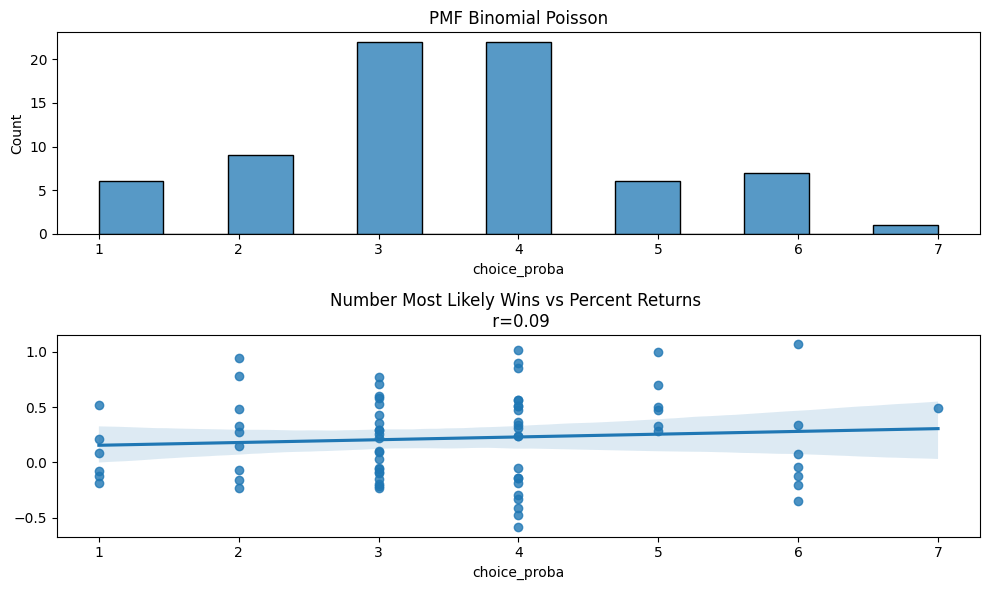

In [4]:
pmf_plot(df_kelly)

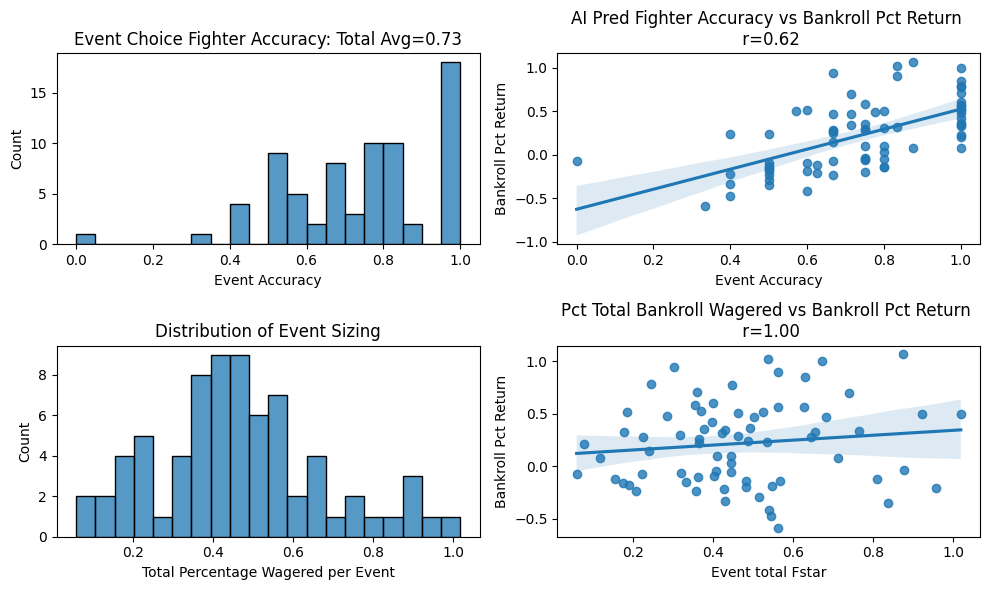

In [4]:
summary_stats(df_kelly)

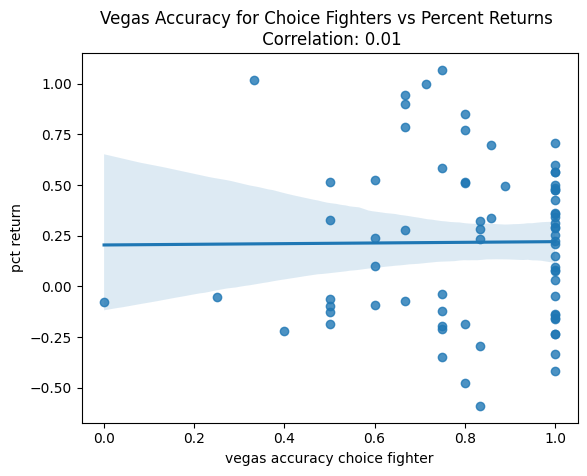

In [5]:
correlate_with_vegas(df_kelly)

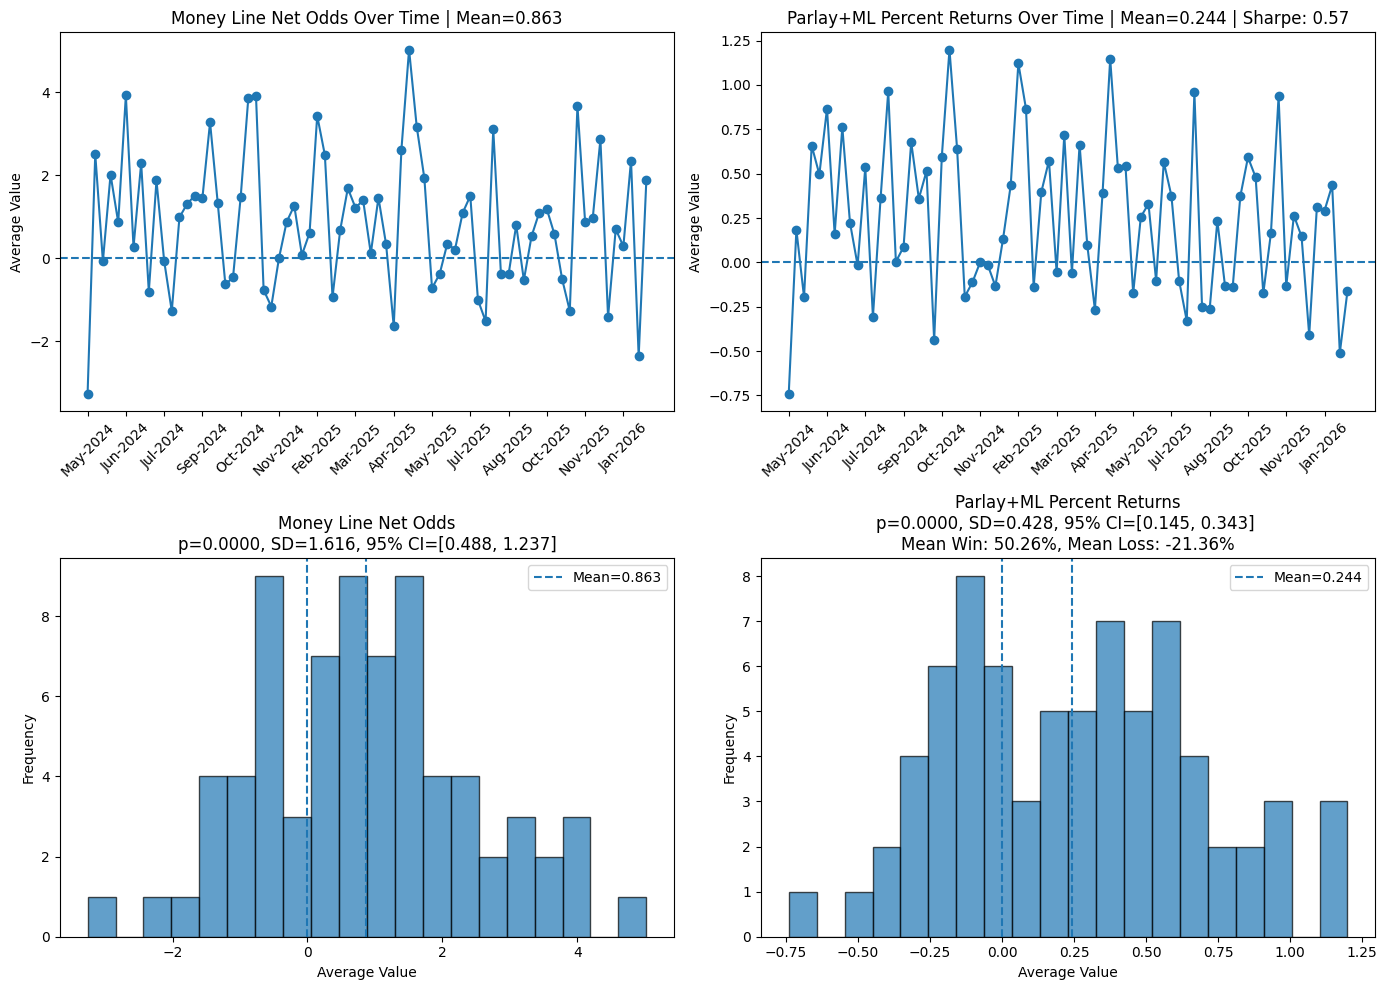

In [15]:
path = r'C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\returns_distributions_open.png'
plot_event_odds_stats(df_kelly, path)

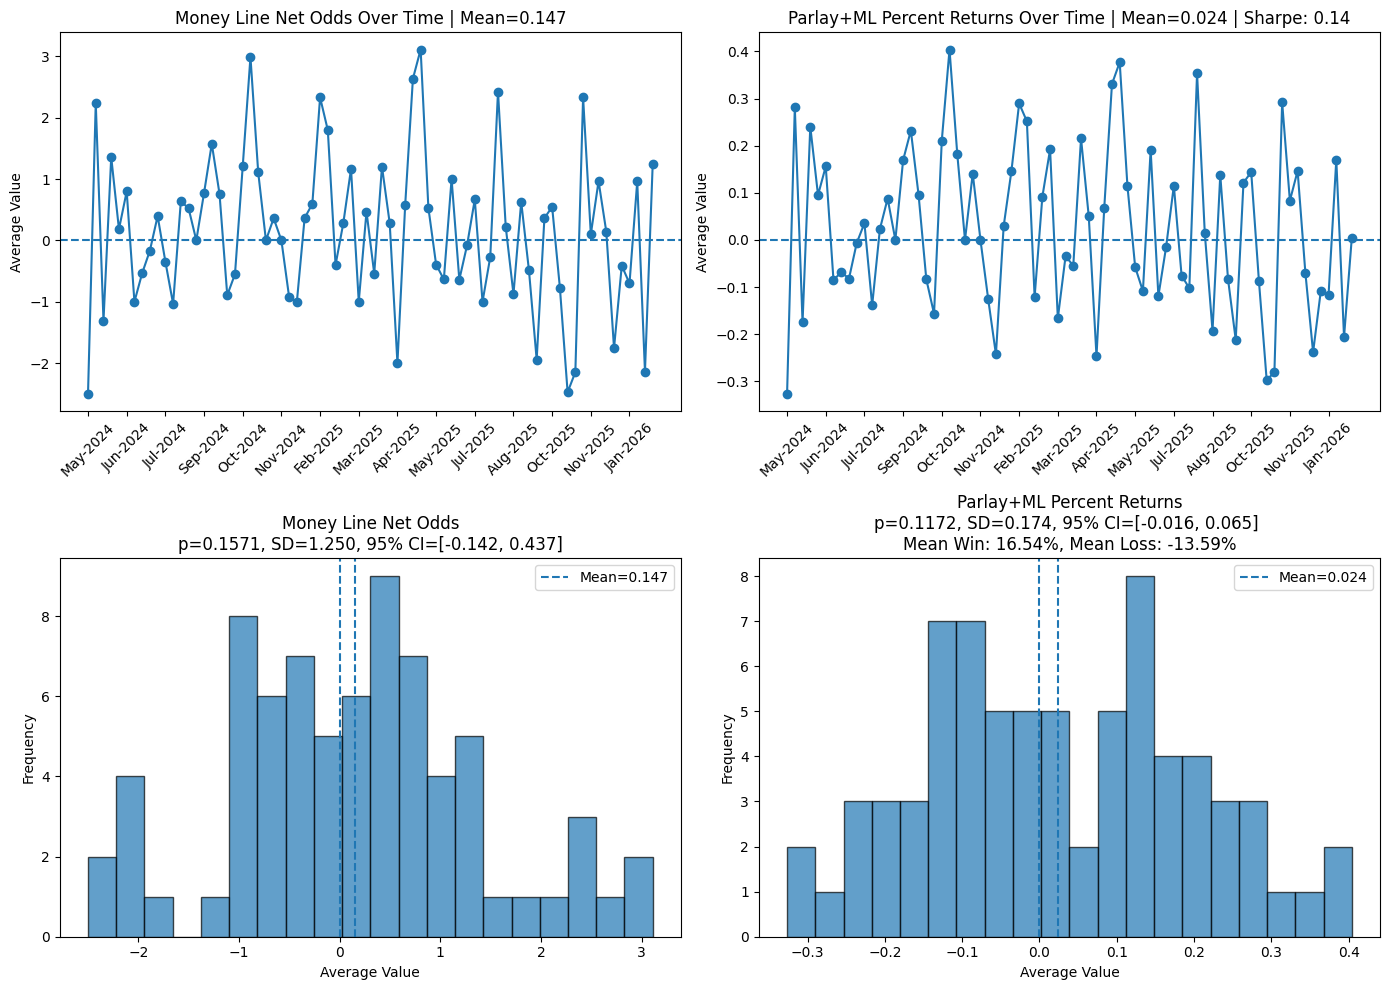

In [16]:
path = r'C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\returns_distributions_close1.png'
plot_event_odds_stats(df_kelly1, path)

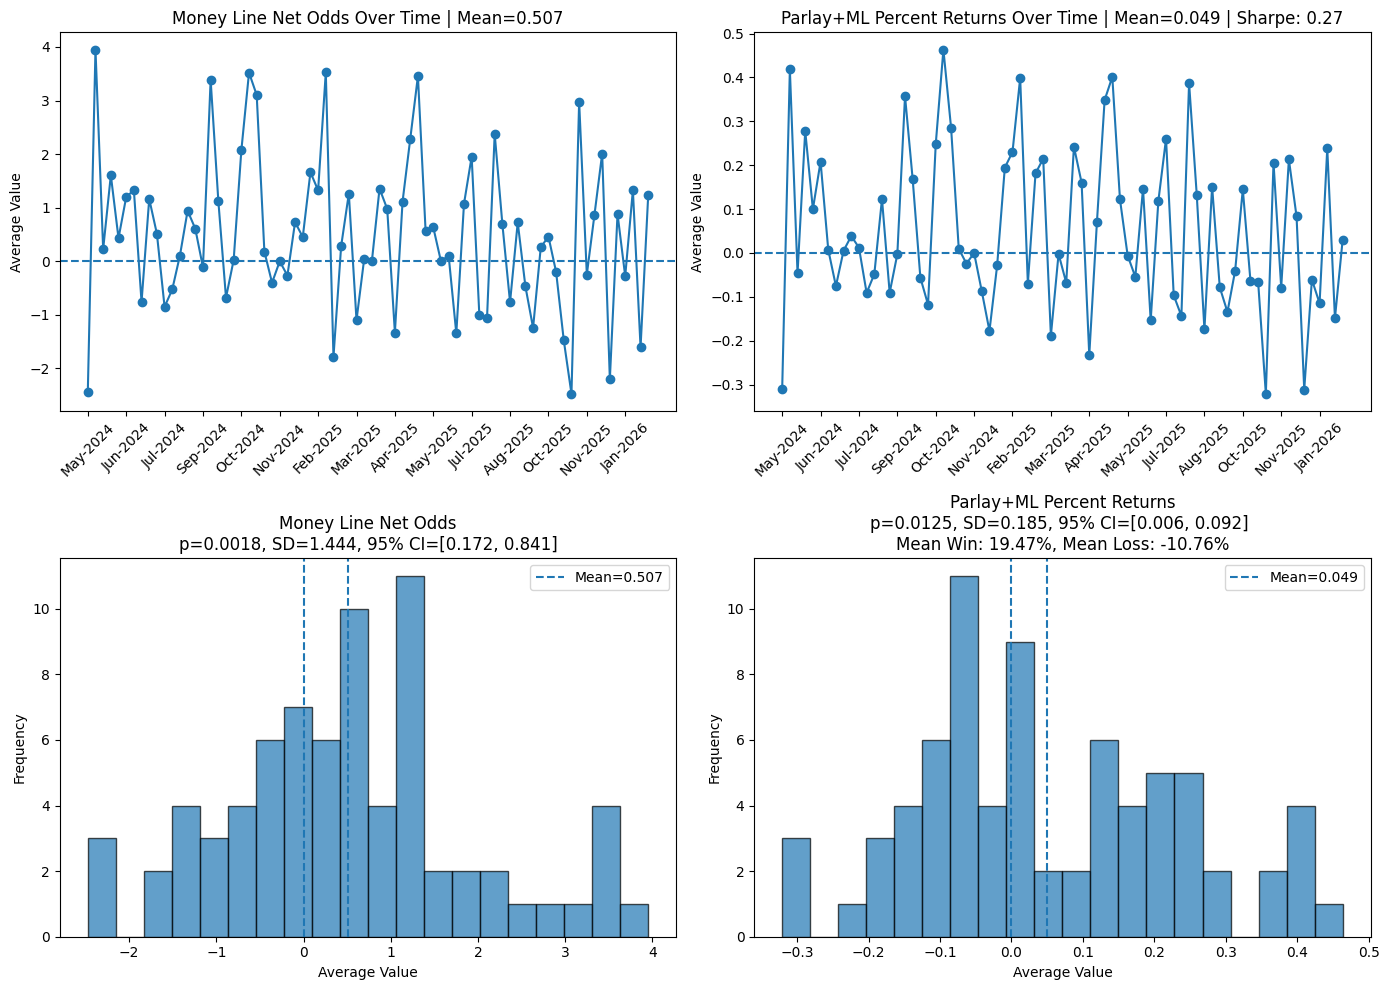

In [17]:
path = r'C:\Users\jcmar\my_files\SportsBetting\Data\plot_pngs\returns_distributions_close2.png'
plot_event_odds_stats(df_kelly2, path)

In [10]:
df_parlay.columns

Index(['choice_fighter_name', 'parlay_fstar_sum', 'parlay_net_odds',
       'choice_fstar', 'choice_ev', 'choice_real_odds', 'date', 'winner',
       'pred_winner', 'choice_proba', 'parlay_prob', 'parlay_ev',
       'parlay_avg_edge', 'fstar_net', 'choice_decimal_odds', 'ev_bin'],
      dtype='object')

In [22]:
df_parlay['parlay_net_odds']

6   -1.000000
5   -1.000000
0   -1.000000
6   -1.000000
0   -1.000000
       ...   
3    0.836478
9   -1.000000
4   -1.000000
7   -1.000000
6   -1.000000
Name: parlay_net_odds, Length: 148, dtype: float64

In [9]:
def calc_parlay_multiplier(df_parlay):

    choice_ev = df_parlay[df_parlay['parlay_ev'] > 0]

    # choice_ev['net_fstar'] = np.where(choice_ev['parlay_net_odds'] < 0, -choice_ev['parlay_fstar_sum'],
    #                     choice_ev['parlay_fstar_sum'])

    total = np.sum(choice_ev['fstar_parlay'] * choice_ev['parlay_net_odds']) / 2
    print(total)

def calc_ml_multiplier(df_kelly):

    choice_kelly = df_kelly[df_kelly['choice_ev'] > 0]

    total = np.sum(choice_kelly['choice_fstar'] * choice_kelly['net_odds'])
    print(total)
    print(f'Total Bets: {choice_kelly.shape[0]}')


In [10]:
calc_parlay_multiplier(df_parlay)
calc_parlay_multiplier(df_kelly1_parlay)
calc_parlay_multiplier(df_kelly2_parlay)

10.827129910169349
0.7005695758878113
0.7830045813441868


In [11]:
calc_ml_multiplier(df_kelly)
calc_ml_multiplier(df_kelly1)
calc_ml_multiplier(df_kelly2)

7.049493326381381
Total Bets: 345
1.076606345628888
Total Bets: 211
2.822197326421276
Total Bets: 341


In [56]:
print(df_parlay.shape, df_kelly1_parlay.shape)

(148, 17) (148, 17)


In [15]:
def compare_parlays(df_open, df_close): 
    assert df_open.shape == df_close.shape, 'shape mismatch'

    choice_open = df_open[df_open['parlay_ev'] > 0]
    open_acc = np.mean(np.where(choice_open['parlay_net_odds'] > 0, 1, 0))
   
    choice_open_close = df_close[df_open['parlay_ev'].values > 0]

    choice_close = df_close[df_close['parlay_ev'] > 0]
    close_acc = np.mean(np.where(choice_close['parlay_net_odds'] > 0, 1, 0))


    n_same = 0
    for date, group in choice_open.groupby('date'):

        group_close = choice_open_close[choice_open_close['date']==date]
        if set(group_close['choice_fighter_name']) == set(group['choice_fighter_name']):

            n_same += 1
    
    avg_net_odds_open = choice_open['parlay_net_odds'].mean()
    avg_net_odds_close = choice_close['parlay_net_odds'].mean()

    print(f'Avg net odds open: {avg_net_odds_open}')
    print(f'Avg net odds close: {avg_net_odds_close}')

    print(f'Close Accuracy: {close_acc}')
    print(f'Open Accuracy: {open_acc}')

    print(f'Percentage of time same parlay: {n_same/(choice_open.shape[0]/2)}')

compare_parlays(df_parlay.reset_index(drop=True), df_kelly1_parlay.reset_index(drop=True))
compare_parlays(df_parlay.reset_index(drop=True), df_kelly2_parlay.reset_index(drop=True))



Avg net odds open: 0.8139441631181218
Avg net odds close: 0.241243682362567
Close Accuracy: 0.5
Open Accuracy: 0.589041095890411
Percentage of time same parlay: 0.3424657534246575
Avg net odds open: 0.8139441631181218
Avg net odds close: 0.2107714338530014
Close Accuracy: 0.4305555555555556
Open Accuracy: 0.589041095890411
Percentage of time same parlay: 0.3013698630136986


In [6]:
def compare_ml(df_kelly, df_kelly1):
    assert df_kelly.shape == df_kelly1.shape, 'wrong shapes'

    choice_kelly = df_kelly[df_kelly['choice_ev'] > 0]
    choice_kelly1 = df_kelly1[df_kelly['choice_ev'] > 0]

    # when open pred is the same as close 
    same_pred = choice_kelly[choice_kelly['pred_winner'] == choice_kelly1['pred_winner']]
    same_pred_kelly1 = choice_kelly1[choice_kelly['pred_winner'] == choice_kelly1['pred_winner']]

    # same pred close ev greater than 0 
    kelly1_same_plus_ev = same_pred_kelly1[same_pred_kelly1['choice_ev'] > 0].shape[0] / same_pred_kelly1.shape[0]

    # same pred average ev change 
    avg_ev_change = same_pred['choice_ev'].mean() - same_pred_kelly1['choice_ev'].mean()

    # avg ev same pred 
    avg_ev_open = same_pred['choice_ev'].mean() 

    # frequency of open pred being the same as close 
    same_pred_frequency = same_pred.shape[0] / choice_kelly.shape[0]

    # accuracy of same pred 
    same_pred_accuracy = np.mean(np.where(same_pred['pred_winner'] == same_pred['winner'], 1, 0))

    # average same pred net odds 
    same_pred_net_avg_open = same_pred['net_odds'].mean()
    same_pred_net_avg_close = same_pred_kelly1['net_odds'].mean()

    print(f'Accuracy of plus ev open fighter with close odds pred: {same_pred_accuracy}')
    print(f'Percentage of time plus ev open fighter same as close odds pred: {same_pred_frequency}')
    print(f'Percentage of time close fighter has plus ev when open fighter has plus ev: {kelly1_same_plus_ev}')
    print(f'Average difference in expected value: {avg_ev_change}')
    print(f'Avg Open plus ev same pred as close: {avg_ev_open}')
    print(f'Same pred open avg net odds: {same_pred_net_avg_open}')
    print(f'Same Pred close net odds average: {same_pred_net_avg_close}')


In [7]:

compare_ml(df_kelly, df_kelly1) 
compare_ml(df_kelly, df_kelly2) 



Accuracy of plus ev open fighter with close odds pred: 0.7387387387387387
Percentage of time plus ev open fighter same as close odds pred: 0.9652173913043478
Percentage of time close fighter has plus ev when open fighter has plus ev: 0.5825825825825826
Average difference in expected value: 0.0813449724871819
Avg Open plus ev same pred as close: 0.10419271041886805
Same pred open avg net odds: 0.1791073976741667
Same Pred close net odds average: 0.04186066390784396
Accuracy of plus ev open fighter with close odds pred: 0.7395209580838323
Percentage of time plus ev open fighter same as close odds pred: 0.9681159420289855
Percentage of time close fighter has plus ev when open fighter has plus ev: 0.8383233532934131
Average difference in expected value: 0.028166864427360452
Avg Open plus ev same pred as close: 0.10493781383165504
Same pred open avg net odds: 0.18306216594460334
Same Pred close net odds average: 0.11775632419536487


In [ ]:
df_parlay['net_fstar'] = np.where(df_parlay['parlay_net_odds'] < 0, -df_parlay['parlay_fstar_sum'],
                        df_parlay['parlay_fstar_sum'])

np.sum(df_parlay['net_fstar'] * df_parlay['parlay_net_odds']) / 2

c:\Users\jcmar\my_files\SportsBetting\BettingStrategy\KellyStrategy\betting_backtest\backtest_plots.py:626: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  accuracy_per_bin = df_parlay.groupby('ev_bin')['parlay_net_odds'].apply(lambda x: (x != -1).sum() / len(x)).reset_index()


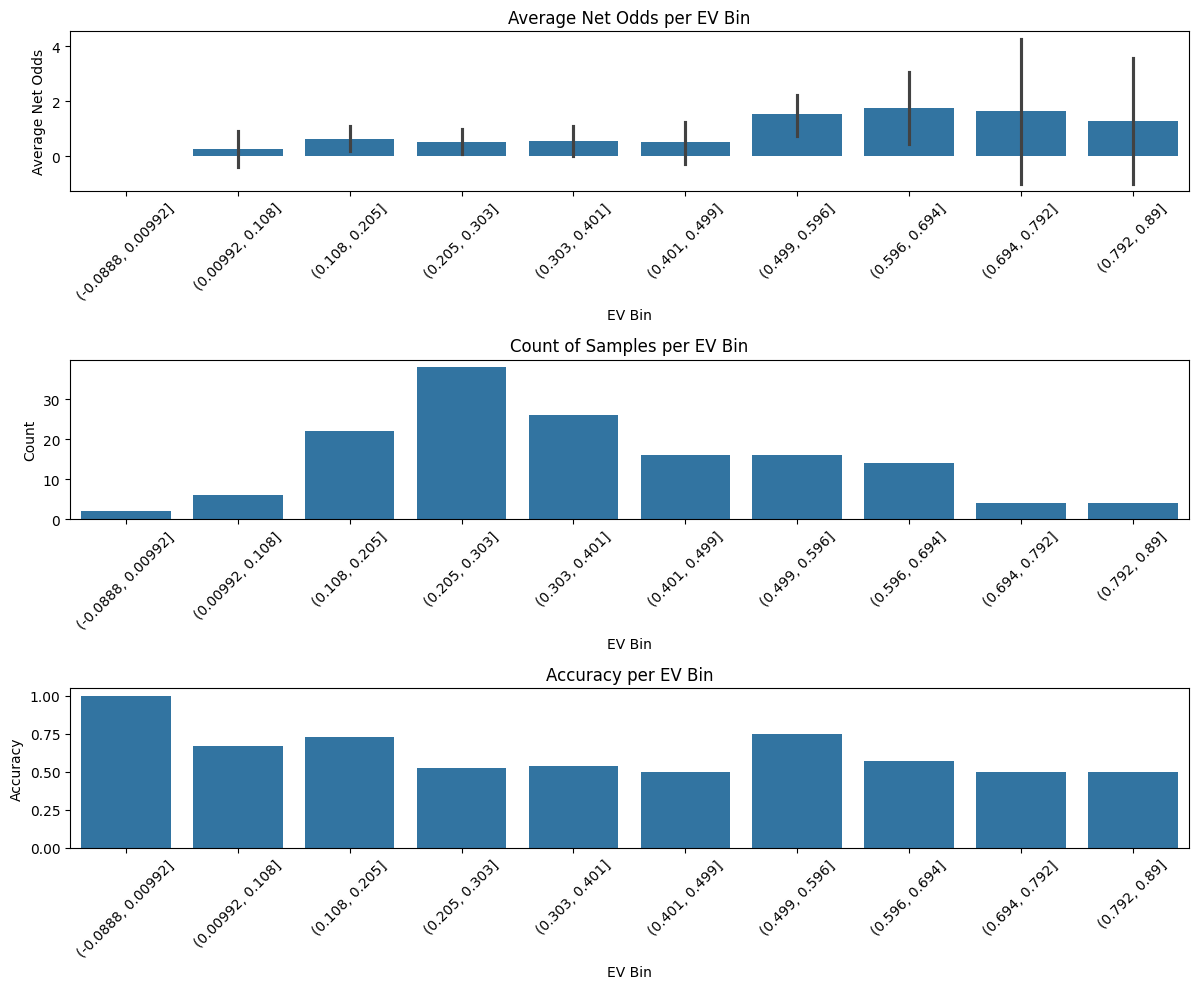

In [7]:
parlay_analysis(df_parlay)

c:\Users\jcmar\my_files\SportsBetting\BettingStrategy\KellyStrategy\betting_backtest\backtest_plots.py:626: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  accuracy_per_bin = df_parlay.groupby('ev_bin')['parlay_net_odds'].apply(lambda x: (x != -1).sum() / len(x)).reset_index()
c:\Users\jcmar\my_files\SportsBetting\BettingStrategy\KellyStrategy\betting_backtest\backtest_plots.py:626: RuntimeWarning: invalid value encountered in scalar divide
  accuracy_per_bin = df_parlay.groupby('ev_bin')['parlay_net_odds'].apply(lambda x: (x != -1).sum() / len(x)).reset_index()


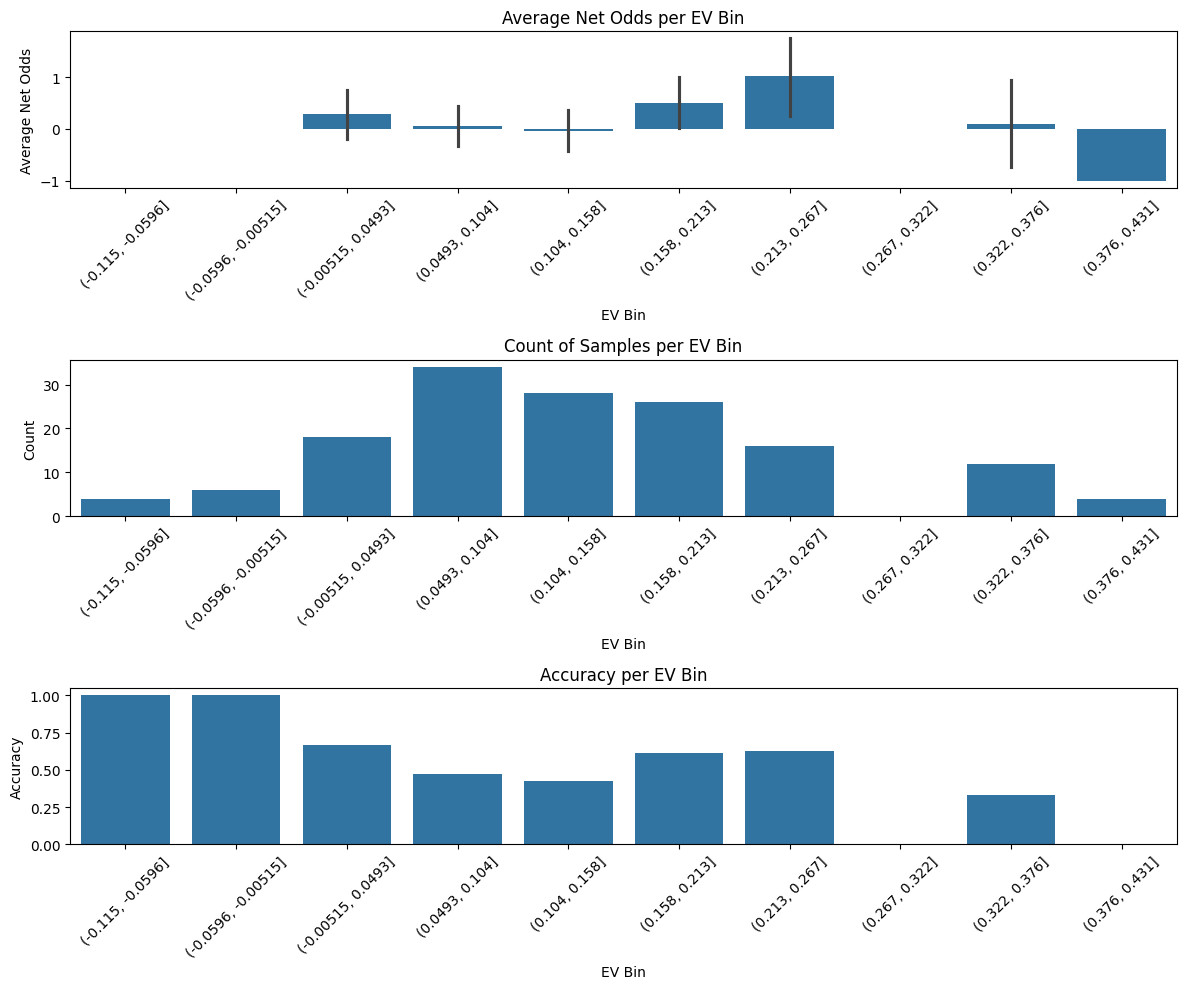

In [6]:
parlay_analysis(df_kelly1_parlay)

c:\Users\jcmar\my_files\SportsBetting\BettingStrategy\KellyStrategy\betting_backtest\backtest_plots.py:627: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  accuracy_per_bin = df_parlay.groupby('ev_bin')['parlay_net_odds'].apply(lambda x: (x != -1).sum() / len(x)).reset_index()
c:\Users\jcmar\my_files\SportsBetting\BettingStrategy\KellyStrategy\betting_backtest\backtest_plots.py:627: RuntimeWarning: invalid value encountered in scalar divide
  accuracy_per_bin = df_parlay.groupby('ev_bin')['parlay_net_odds'].apply(lambda x: (x != -1).sum() / len(x)).reset_index()


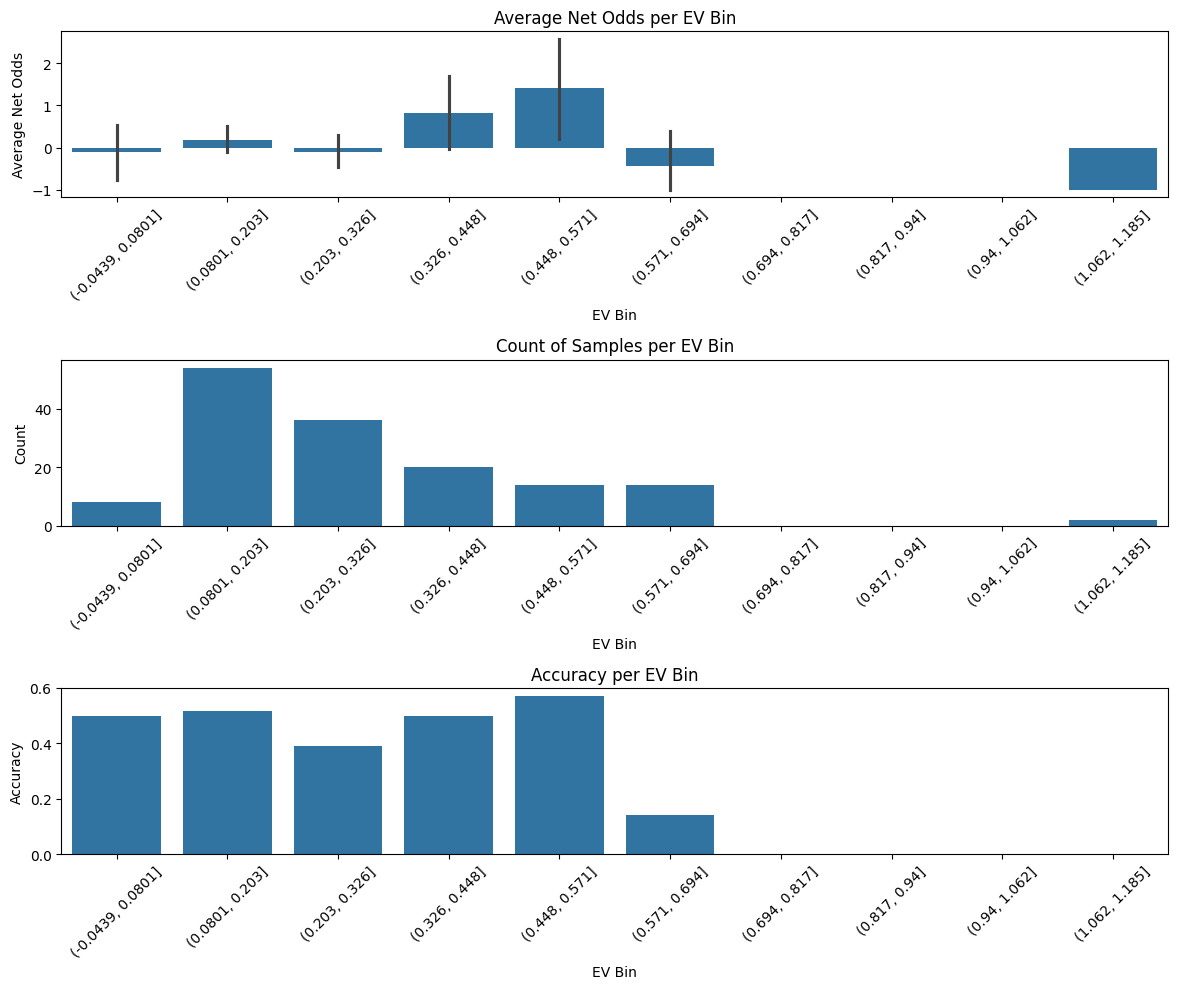

In [5]:
parlay_analysis(df_kelly2_parlay)

In [9]:
df_kelly2_parlay[df_kelly2_parlay['parlay_ev'] > .57].shape

(16, 14)

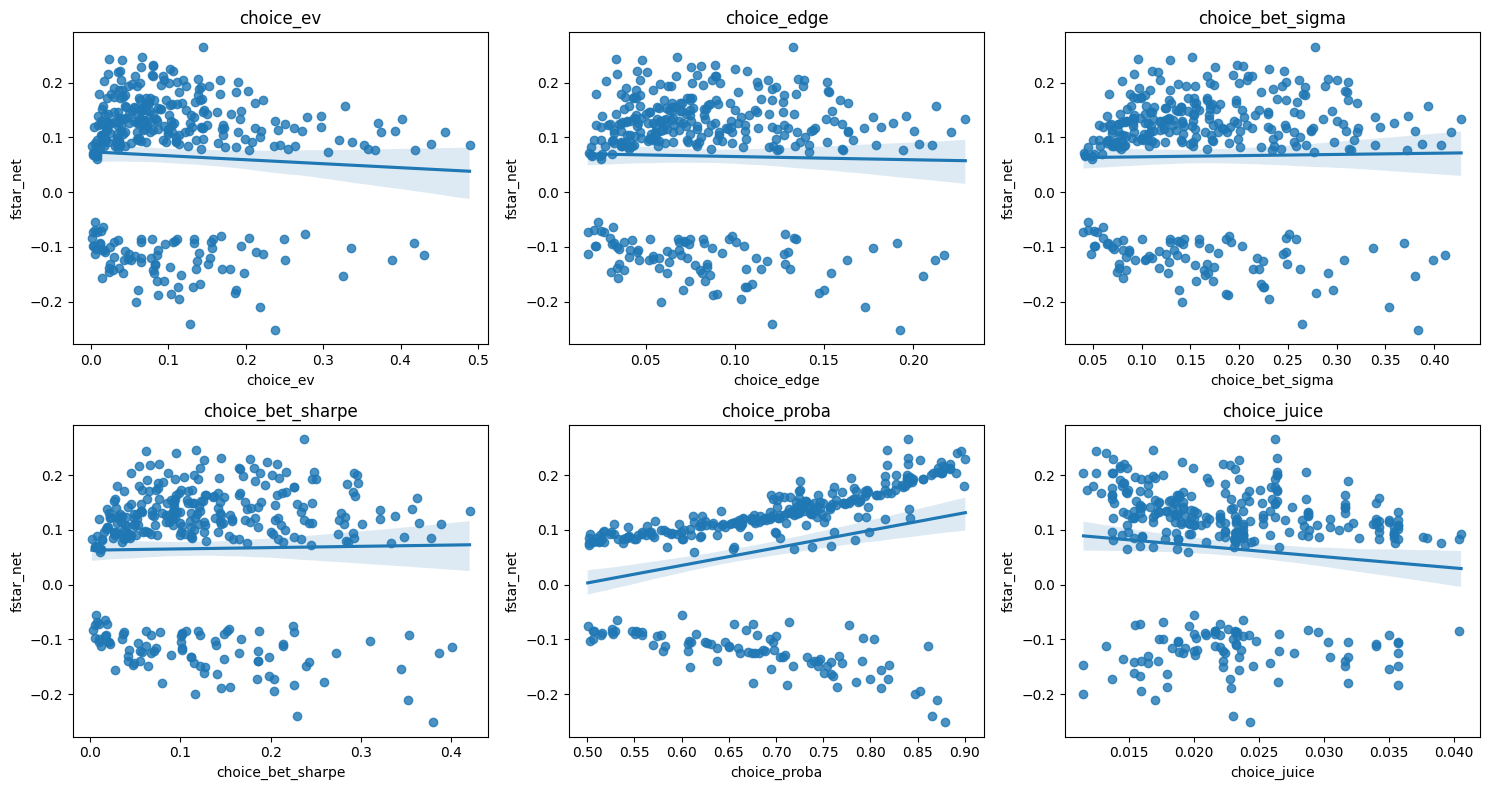

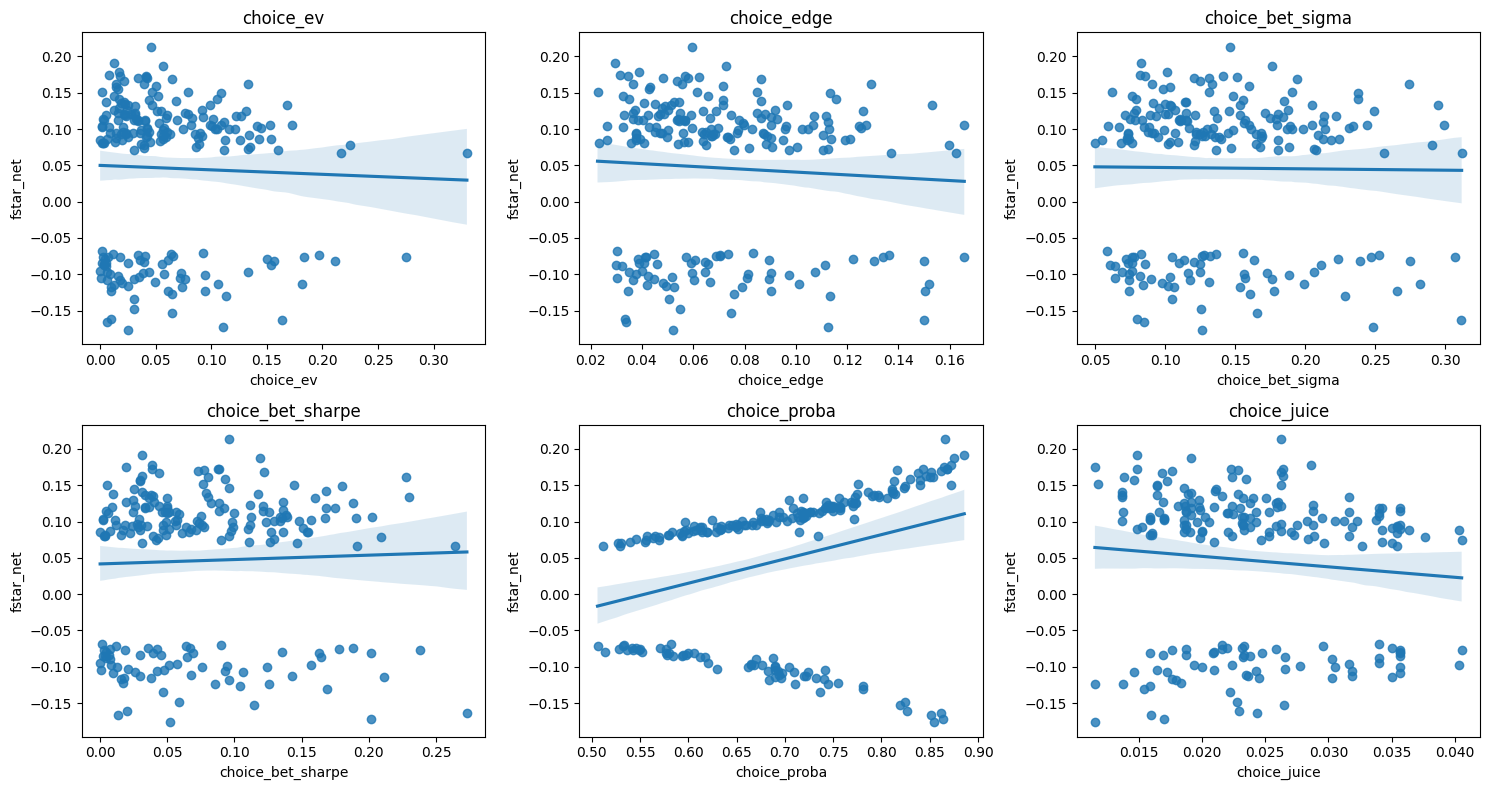

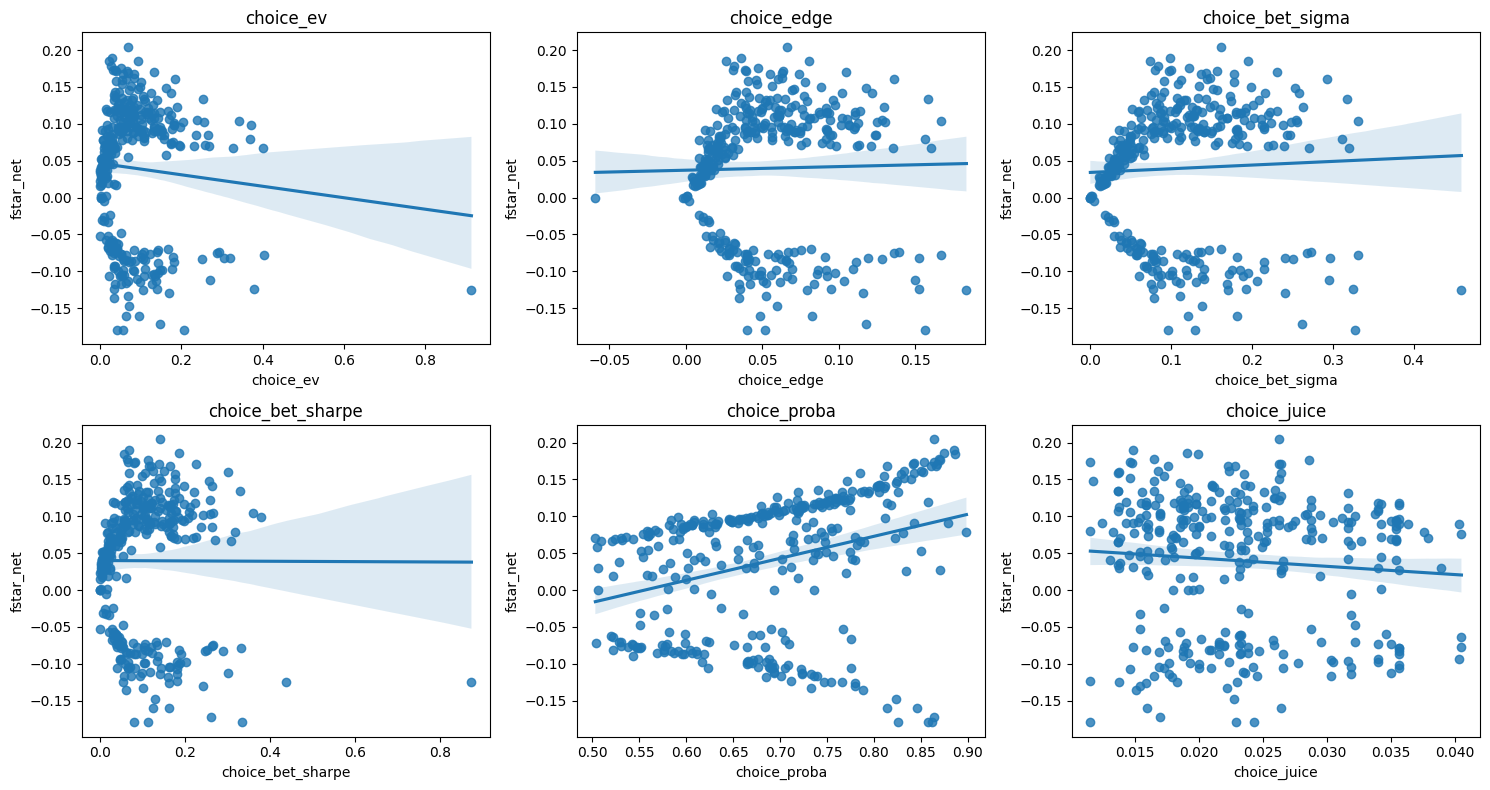

In [9]:
per_bet_analysis(df_kelly)
per_bet_analysis(df_kelly1)
per_bet_analysis(df_kelly2)

In [8]:
pct_positive = (
    df_kelly.groupby('date')['parlay_net_odds']
      .first()
      .gt(0)
      .mean()
)

pct_positive

np.float64(0.5)

https://wayback.archive-it.org/5456/20240920160238/https://www.eecs.harvard.edu/cs286r/courses/fall12/papers/Thorpe_KellyCriterion2007.pdf

https://medium.com/raposa-technologies/how-to-use-python-and-the-kelly-criterion-to-optimize-your-stock-portfolio-bb6e43df50c2



In [ ]:
https://web3.arxiv.org/abs/2207.14124?utm_source=chatgpt.com

https://pubmed.ncbi.nlm.nih.gov/35205582/

https://summit.sfu.ca/item/34958?utm_source=chatgpt.com


https://www.glicko.net/glicko/glicko2.pdf

https://www.glicko.net/glicko.html

https://ojs.aaai.org/index.php/AIIDE/article/view/5233


https://arxiv.org/abs/2303.16741?utm_source=chatgpt.com

https://opisthokonta.net/?cat=48


https://dashee87.github.io/football/python/predicting-football-results-with-statistical-modelling-dixon-coles-and-time-weighting/

